# Inverse Problems Exercises: 2023s s01 (all)
https://www.umm.uni-heidelberg.de/miism/

## Notes
* Please **DO NOT** change the name of the `.ipynb` file. 
* Please **DO NOT** import extra packages to solve the tasks. 
* Please put the `.ipynb` file directly into the `.zip` archive without any intermediate folder. 

## Please provide your personal information
* full name (Name): 

Jan Benda

## I05: Parabolic trajectory problem

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Forward problem
Assume that we observe a ball thrown perpendicular to the earth's
surface to the sky. By ignoring friction, we can write the equation of motion
as the height $g$ as a function of time $t$ as 
$$g_i = g(t_i) = f_0 + f_1 t_i + \frac{1}{2} f_2 t_i^2 = \begin{bmatrix} 1 & t_i & \frac{1}{2} t_i^2 \end{bmatrix} \begin{bmatrix} f_0 \\ f_1 \\ f_2 \end{bmatrix} .$$

* Given $f_\text{true} = \begin{bmatrix} f_0 \\ f_1 \\ f_2 \end{bmatrix} = \begin{bmatrix} 1 \\ 25 \\ -4 \end{bmatrix}$
* Given $t_i = (0.0, 0.5, 1.0, ..., 9.0, 9.5)$
* Calculate $g_i = g(t_i)$
* Save the output in the variables `f_true`, `t` and `g`, respectivly (as `numpy.array`)
* Plot `g` versus `t` in the axes `ax`

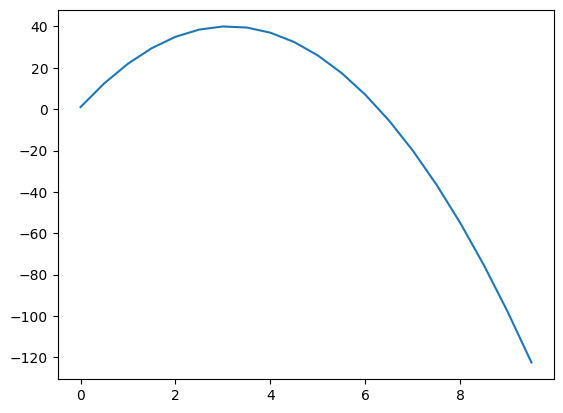

In [2]:

f_true = np.array([1,25,-4])

t = np.linspace(0,10,20,endpoint = False )
g = np.array([ f_true @ np.array([1,ti,ti**2]) for ti in t])



fig, ax = plt.subplots()  # Create a figure and an axes.

ax.plot(t, g)

In [3]:
# This cell contains hidden tests.



In [4]:
# This cell contains hidden tests.


### Inverse problem
Collecting all measurements, we obtain the system of equations
$$g = \begin{bmatrix} g_1 \\ ... \\ g_n \end{bmatrix}
= \begin{bmatrix} 1 & t_1 & \frac{1}{2} t_1^2 \\ ... & ... & ... \\ 1 & t_n & \frac{1}{2} t_n^2 \end{bmatrix}
\begin{bmatrix} f_0 \\ f_1 \\ f_2 \end{bmatrix}
= A f .$$
When the number of measurements is the same as the number of parameters, $A$ is square. The solution involves the inverse as 
$$\hat{f} = A^{-1} g .$$

* Take the last 3 elements from `t` and `g`
* Calculate $A$ and $\hat{f}$ 
* Save the output in the variables `A` and `f_est`, respectivly (as `numpy.array`)

In [5]:
# YOUR CODE HERE
t_last = t[-3:]
g_last = g[-3:]

A = np.c_[np.ones(3),t_last,0.5*t_last**2]

A_inv = np.linalg.inv(A)
f_est = A_inv @ g_last 

In [6]:
# This cell contains tests.


print(A)
print(f_est)

[[ 1.     8.5   36.125]
 [ 1.     9.    40.5  ]
 [ 1.     9.5   45.125]]
[ 1. 25. -8.]


### Measurement errors
The real measurements usually contain noise. In the case of additive Gaussian noise, the problem is formulated as
$$g' = g + \epsilon = Af + \epsilon ,$$
where $\epsilon$ is a random variable with Gaussian distribution with mean $0$ and variance $\sigma^2$, i.e. $\epsilon \sim \mathcal{N}(0,\sigma^2)$. The solution involves the inverse as 
$$\hat{f} = A^{-1} g' .$$

* Given $\sigma = 2$
* Calculate $g'$
* Save the output in the variable `g_n` (as `numpy.array`)
* Plot `g` versus `t` in the axes `ax`
* Plot `g_n` versus `t` in the axes `ax` as well
* Show the legend in the axes `ax`
* Take the last 3 elements from `t` and `g_n`
* Calculate $A$ and $\hat{f}$ 
* Save the output in the variables `A` and `f_est`, respectivly (as `numpy.array`)

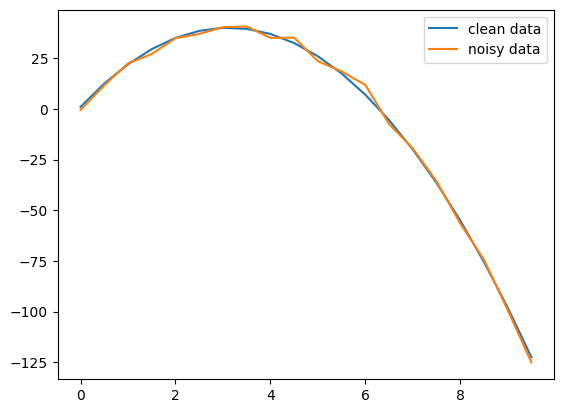

In [7]:
# YOUR CODE HERE
g_n = g+np.random.normal(0,2,np.shape(g))


fig, ax = plt.subplots()  # Create a figure and an axes.

ax.plot(t,g, label = "clean data")
ax.plot(t,g_n, label = "noisy data")
ax.legend()

g_last = g_n[-3:]

#t and A were calculated in previous block

f_est = A_inv @ g_last 



In [8]:
# This cell contains hidden tests.


In [9]:
# This cell contains hidden tests.


In [10]:
# This cell contains tests.


print(f_est)

[176.21432503 -10.58046443  -4.44887193]


### Question: Noise
* How does the result depend on the noise?

Estimated values are far from our original data. We think it is due to matrix $A^{-1}$ having a large condition number, so even a small perturbation no vector $g$ will cause a large error in our result after multiplying $g$ with $A^{-1}$.

### Pseudo-inverse
When the number of measurements is larger than the number of parameters, $A$ is generally not invertible. The solution involves the pseudo-inverse as 
$$\hat{f} = (A^T A)^{-1} A^T g = A^{PI} g' .$$

* Take all elements from `t` and `g_n`
* Calculate $A$ and $\hat{f}$ 
* Save the output in the variables `A` and `f_est`, respectivly (as `numpy.array`)

In [11]:
# YOUR CODE HERE
A = np.c_[np.ones(np.shape(t)),t,0.5*t**2]
pseudo_A =np.linalg.inv(A.T @ A) @ A.T

f_est = pseudo_A @ g_n



In [12]:
# This cell contains tests.


print(A)
print(f_est)

[[ 1.     0.     0.   ]
 [ 1.     0.5    0.125]
 [ 1.     1.     0.5  ]
 [ 1.     1.5    1.125]
 [ 1.     2.     2.   ]
 [ 1.     2.5    3.125]
 [ 1.     3.     4.5  ]
 [ 1.     3.5    6.125]
 [ 1.     4.     8.   ]
 [ 1.     4.5   10.125]
 [ 1.     5.    12.5  ]
 [ 1.     5.5   15.125]
 [ 1.     6.    18.   ]
 [ 1.     6.5   21.125]
 [ 1.     7.    24.5  ]
 [ 1.     7.5   28.125]
 [ 1.     8.    32.   ]
 [ 1.     8.5   36.125]
 [ 1.     9.    40.5  ]
 [ 1.     9.5   45.125]]
[-0.78438287 25.92184799 -8.18475256]


In [13]:
# This cell contains hidden tests.


### Question: Data
* How does the result depend on the number of considered data?

When we used pseudoinverse to estimate $f$, we got much better result. The more data we used to approximate $f$, the better the approximation was.